# Project Work on the topic of "Crop Yield prediction in Agriculture"

<img src="https://i0.wp.com/geopard.tech/wp-content/uploads/2022/06/63-min.jpg?w=1200&ssl=1" style="width: 100%; height: auto;" />

<!-- https://www.slideteam.net/media/catalog/product/cache/1280x720/s/m/smart_with_weather_forecast_trend_precision_farming_system_for_environmental_sustainability_iot_ss_v_slide01.jpg -->
<img src="https://www.slideteam.net/media/catalog/product/cache/1280x720/s/m/smart_with_weather_forecast_trend_precision_farming_system_for_environmental_sustainability_iot_ss_v_slide01.jpg" style="width: 100%; height: auto;" />

<!-- <img src="https://ars.els-cdn.com/content/image/1-s2.0-S2772375525004940-gr013.jpg" style="width: 100%; height: auto;" /> -->

![Excel - Smart farming.png](<attachment:Excel - Smart farming.png>)
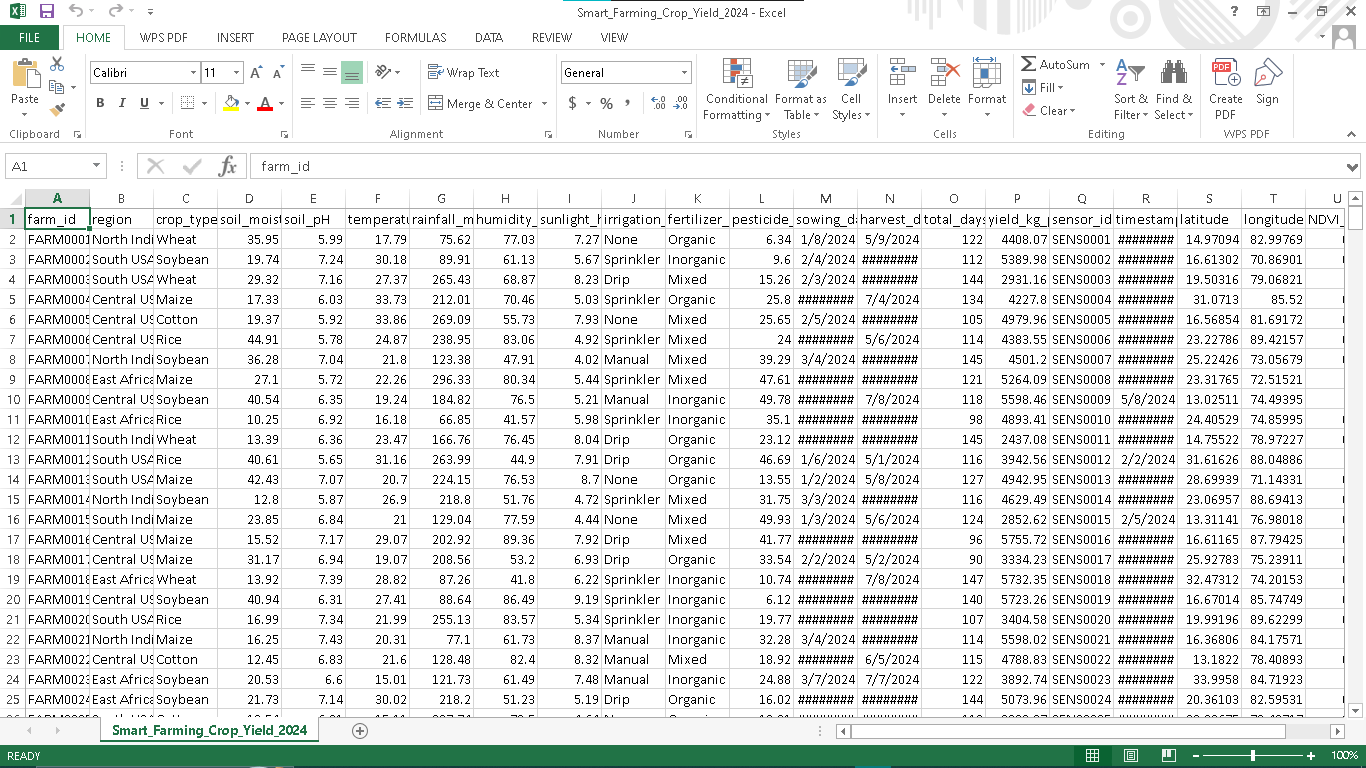

# Table of Contents

- [Introduction](#Introduction)
- [Data Collection](#Quick-look-at-the-data-structure)
- [Data Cleaning](#Data-Cleaning)
- [Visualization](#Visualization)
- [Conclusion](#Conclusion)

## Introduction

In [1]:
import pandas as pd         #Data handling and analysis
sf = pd.read_csv("Smart_Farming_Crop_Yield_2024.csv")
sf

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,FARM0496,Central USA,Rice,42.85,6.70,30.85,52.35,79.58,7.25,Manual,...,2024-01-16,2024-06-02,138,4251.40,SENS0496,2024-05-08,30.386623,76.147700,0.59,Mild
496,FARM0497,North India,Soybean,34.22,6.75,17.46,256.23,45.14,5.78,NaN,...,2024-01-01,2024-04-14,104,3708.54,SENS0497,2024-01-19,18.832748,75.736924,0.85,Severe
497,FARM0498,North India,Cotton,15.93,5.72,17.03,288.96,57.87,7.69,Drip,...,2024-01-02,2024-05-09,128,2604.41,SENS0498,2024-04-20,23.262016,81.992230,0.71,Mild
498,FARM0499,Central USA,Soybean,38.61,6.20,17.08,279.06,73.09,9.60,Drip,...,2024-01-25,2024-06-04,131,2586.36,SENS0499,2024-03-02,19.764989,84.426869,0.77,Severe


## Quick look at the data structure

In [2]:
import numpy as np              #Numerical calculations
import matplotlib.pyplot as plt # Visualization and plotting
import seaborn as sns           # Advanced and beautiful visualization

## Select Important Columns


In [3]:
sf = sf[['farm_id', 'crop_type', 'temperature_C', 'soil_moisture_%',
         'soil_pH', 'sunlight_hours', 'yield_kg_per_hectare',
         'region', 'crop_disease_status', 'sensor_id',
         'irrigation_type']]

## Data Cleaning

In [4]:
sf.dropna(inplace=True)
sf

,farm_id,crop_type,temperature_C,soil_moisture_%,soil_pH,sunlight_hours,yield_kg_per_hectare,region,crop_disease_status,sensor_id,irrigation_type
2,FARM0003,Wheat,27.37,29.32,7.16,8.23,2931.16,South USA,Mild,SENS0003,Drip
7,FARM0008,Maize,22.26,27.10,5.72,5.44,5264.09,East Africa,Mild,SENS0008,Sprinkler
8,FARM0009,Soybean,19.24,40.54,6.35,5.21,5598.46,Central USA,Mild,SENS0009,Manual
9,FARM0010,Rice,16.18,10.25,6.92,5.98,4893.41,East Africa,Severe,SENS0010,Sprinkler
10,FARM0011,Wheat,23.47,13.39,6.36,8.04,2437.08,South India,Moderate,SENS0011,Drip
...,...,...,...,...,...,...,...,...,...,...,...
491,FARM0492,Maize,21.49,32.14,7.44,5.58,4503.82,North India,Mild,SENS0492,Sprinkler
493,FARM0494,Cotton,22.37,18.11,6.95,5.09,4590.26,South India,Mild,SENS0494,Sprinkler
495,FARM0496,Rice,30.85,42.85,6.70,7.25,4251.40,Central USA,Mild,SENS0496,Manual
497,FARM0498,Cotton,17.03,15.93,5.72,7.69,2604.41,North India,Mild,SENS0498,Drip


# Basic Information


In [5]:
print("\nDataset Information")
print(sf.info())


Dataset Information
<class 'pandas.DataFrame'>
Index: 255 entries, 2 to 498
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               255 non-null    str    
 1   crop_type             255 non-null    str    
 2   temperature_C         255 non-null    float64
 3   soil_moisture_%       255 non-null    float64
 4   soil_pH               255 non-null    float64
 5   sunlight_hours        255 non-null    float64
 6   yield_kg_per_hectare  255 non-null    float64
 7   region                255 non-null    str    
 8   crop_disease_status   255 non-null    str    
 9   sensor_id             255 non-null    str    
 10  irrigation_type       255 non-null    str    
dtypes: float64(5), str(6)
memory usage: 23.9 KB
None


## Visualization

# 1. Crop Type Analysis


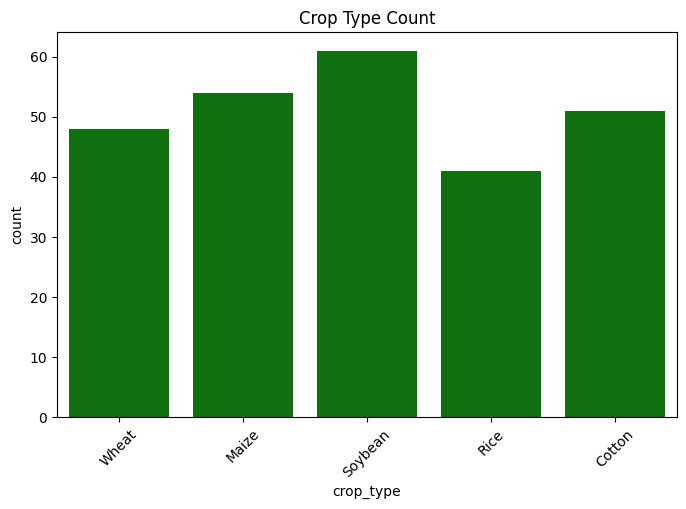

In [6]:
# Bar Chart - Crop Count
plt.figure(figsize=(8,5))
sns.countplot(x='crop_type', data=sf, color='g')
plt.title("Crop Type Count")
plt.xticks(rotation=45)
plt.show()

# 2. Distribution of Crop Yields

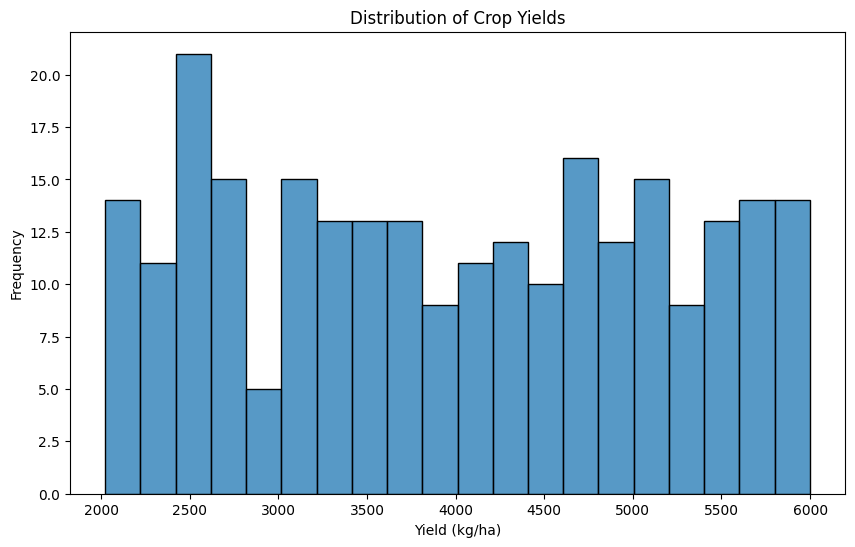

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(sf["yield_kg_per_hectare"], bins=20)
plt.title('Distribution of Crop Yields')
plt.xlabel('Yield (kg/ha)')
plt.ylabel('Frequency')
plt.show()


# 3. Crop Types Over Time

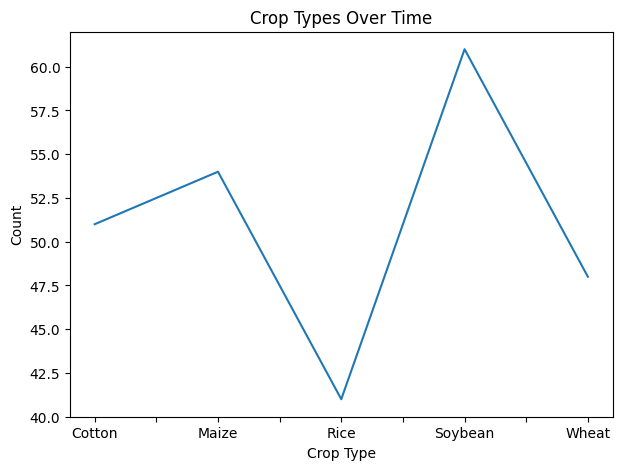

In [8]:
plt.figure(figsize=(7,5))
sf['crop_type'].value_counts().sort_index().plot(kind='line')
plt.title('Crop Types Over Time')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.show()  

# 4. Pie Chart - Crop Distribution


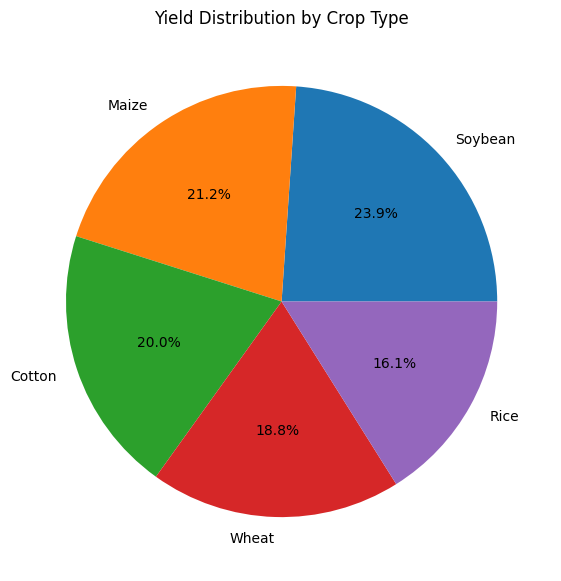

In [9]:
yield_category = sf['crop_type'].value_counts()

plt.figure(figsize=(10,7))
yield_category.plot(kind='pie', autopct='%1.1f%%')
plt.title("Yield Distribution by Crop Type")
plt.show()

# 5. Horizontal Bar Chart - Region Wise Farm Count

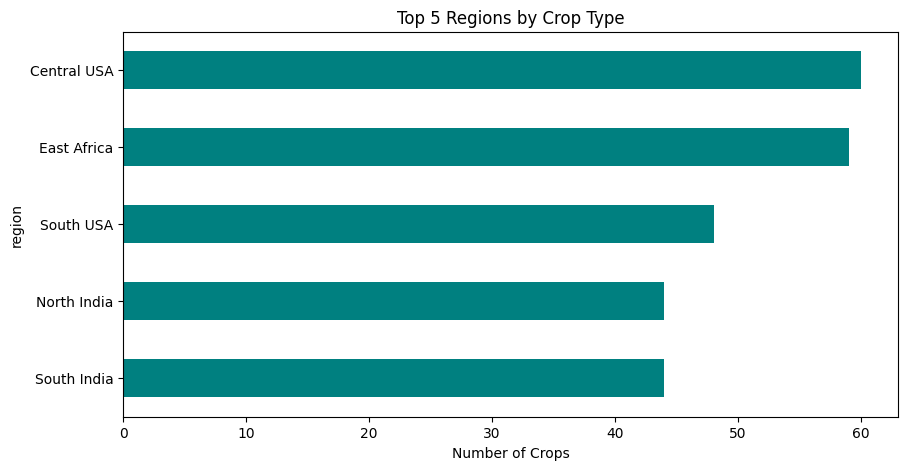

In [10]:
item_region = sf.groupby('region')['crop_type'].count().sort_values(ascending=True).head(5)

plt.figure(figsize=(10,5))
item_region.plot(kind='barh', color='teal')
plt.title("Top 5 Regions by Crop Type")
plt.xlabel("Number of Crops")
plt.show()

# 6. Most Used Irrigation Type


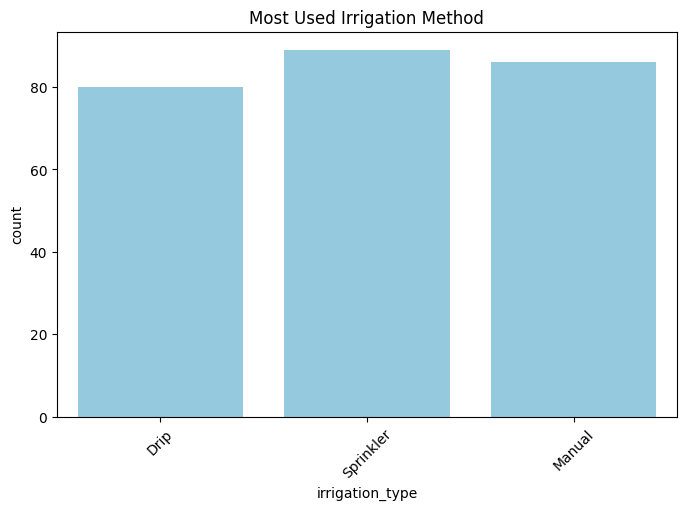

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='irrigation_type', data=sf,color='skyblue')
plt.title("Most Used Irrigation Method")
plt.xticks(rotation=45)
plt.show()

# 7. Disease Analysis


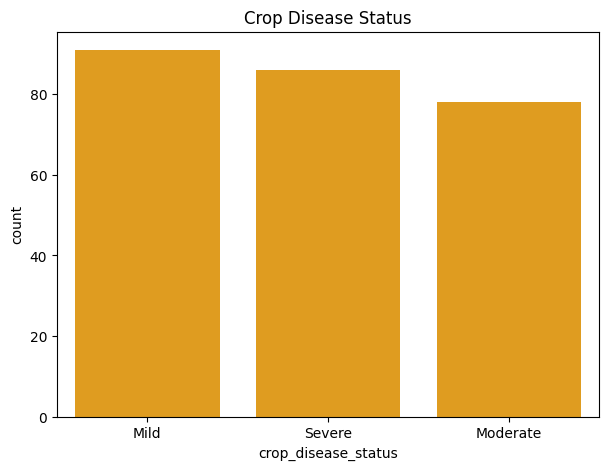

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(x='crop_disease_status', data=sf,color='orange')
plt.title("Crop Disease Status")
plt.show()

# 8 .Box Plot - Yield vs Disease Status


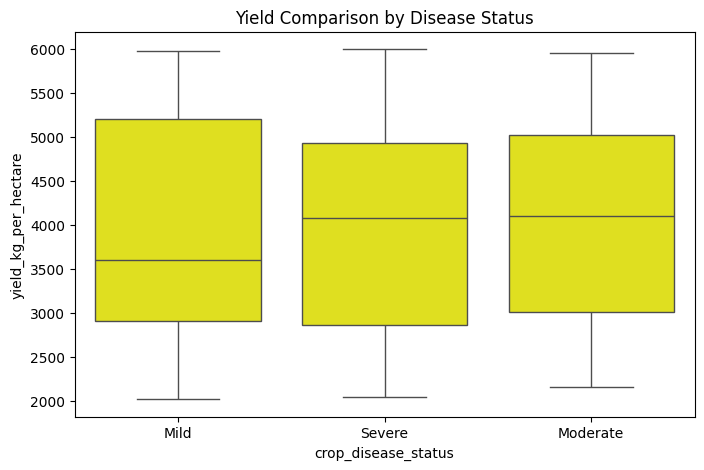

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='crop_disease_status', y='yield_kg_per_hectare', data=sf, color='yellow')
plt.title("Yield Comparison by Disease Status")
plt.show()

# 9. Box Plot - Yield Range


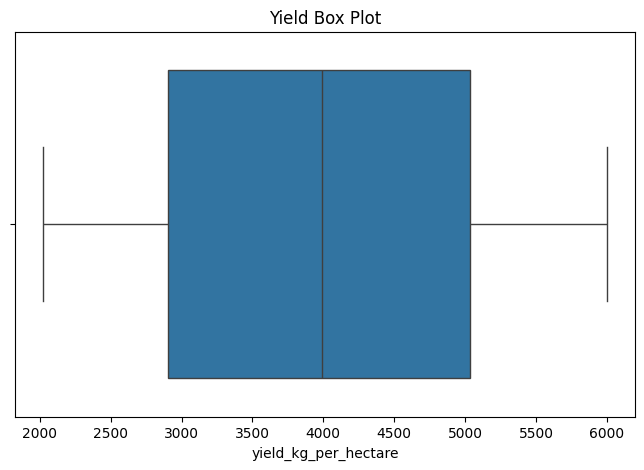

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=sf['yield_kg_per_hectare'])
plt.title("Yield Box Plot")
plt.show()

# 10. Environmental Factor Analysis


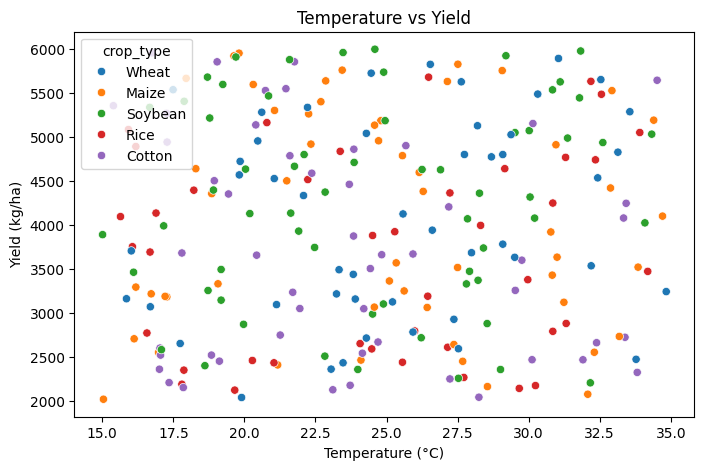

In [15]:
# Temperature vs Yield
plt.figure(figsize=(8,5))
sns.scatterplot(x='temperature_C', y='yield_kg_per_hectare', data=sf,hue='crop_type', color='red')
plt.title("Temperature vs Yield")
plt.xlabel("Temperature (°C)")
plt.ylabel("Yield (kg/ha)")
plt.show()


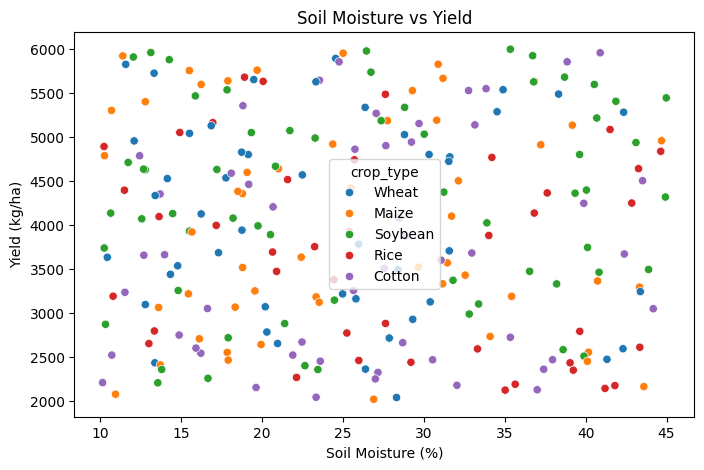

In [16]:
# Soil Moisture vs Yield
plt.figure(figsize=(8,5))
sns.scatterplot(x='soil_moisture_%', y='yield_kg_per_hectare', data=sf,hue='crop_type', color='green')
plt.title("Soil Moisture vs Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (kg/ha)")
plt.show()

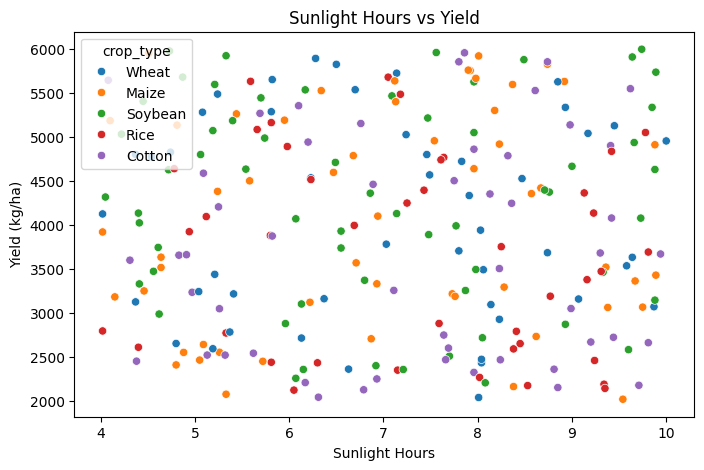

In [17]:
# Sunlight vs Yield
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='sunlight_hours',
    y='yield_kg_per_hectare',
    data=sf,
    hue='crop_type'
)

plt.title("Sunlight Hours vs Yield")
plt.xlabel("Sunlight Hours")
plt.ylabel("Yield (kg/ha)")

plt.show()

# 11. Final Insights


In [18]:
print("\n========== PROJECT INSIGHTS ==========")

print("\nMost Common Crop Type:")
print(sf['crop_type'].mode()[0])

print("\nBest Irrigation Type Based on Yield:")
avg_yield = sf.groupby('irrigation_type')['yield_kg_per_hectare'].mean()
print(avg_yield.idxmax())

print("\nAverage Yield:")
print(sf['yield_kg_per_hectare'].mean())

print("\nRegion with Highest Average Yield:")
print(sf.groupby('region')['yield_kg_per_hectare'].mean().idxmax())

print("\n======================================")


========== PROJECT INSIGHTS ==========

Most Common Crop Type:
Soybean

Best Irrigation Type Based on Yield:
Sprinkler

Average Yield:
3990.6692549019604

Region with Highest Average Yield:
South India



# Conclusion

Crop yield prediction is an important part of smart farming. It helps farmers estimate crop production, reduce loss, and improve profit. Factors like rainfall, soil quality, temperature, irrigation, and fertilizers directly affect crop yield.

Machine Learning and AI are transforming agriculture by providing accurate predictions, disease detection, smart irrigation, and automated farming solutions. These technologies help farmers make better decisions and improve productivity.

In the future, smart farming with AI and Machine Learning will play a major role in solving food production challenges and supporting sustainable agriculture.